# Loading your BWK sample points.
## Loading packages
Let's start with installing the required packages.

In [161]:
try:
    import ee, geemap
except ImportError:
    !pip -q install earthengine-api geemap

import ee, geemap, datetime # ee: Google Earth Engine (GEE) API, geemap: mapping GEE products
import pandas as pd
import matplotlib.pyplot as plt # for figure plotting
import geopandas as gpd # for geospatial dataframes
import os

In [162]:
%pip install "leafmap[maplibre]" # For interactive visualization of maps.
from maplibre.plugins import MapboxDrawControls, MapboxDrawOptions # To select ROI's on your maps.

Connect to your Google Drive to load your dataset within your drive.

In [163]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Load your geospatial dataset.

In [164]:
grasslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/Grassland_classified_final_classes_2020.gpkg")
nograsslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/NoGrassland_classified_final_classes_2020.gpkg")

Create a random subset of nograsslands of +/- 30% of the grasslands dataset.

In [165]:
samplesize = round(len(grasslands) * 30  / 100)
samplesize

2204

In [166]:
nograsslands_samp = nograsslands.sample(n=samplesize, random_state=42)
len(nograsslands_samp)

2204

Combine the datasets

In [167]:
list(grasslands)

['lg_2022',
 'lg_2016',
 'lg_2017',
 'lg_2018',
 'lg_2019',
 'lg_2020',
 'lg_2021',
 'l_7_BWK',
 'lg_2023',
 'Tl_2023',
 'l_8_BWK',
 'FID_BWK',
 'OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABE',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHA',
 'HABLEGE',
 'LENGTE',
 'OPPERVL',
 'FID_L20',
 'ORIG_FI',
 'Shp_Lng',
 'Shap_Ar',
 'combi',
 'Level1',
 'Level2',
 'Level3',
 'Level4',
 'Level5',
 'Level4_int_class',
 'geometry']

In [168]:
list(nograsslands_samp)

['OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABEL',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHAB',
 'HABLEGENDE',
 'LENGTE',
 'OPPERVL',
 'geometry']

In [169]:
nograsslands_samp = nograsslands_samp.assign(Level4='nograss')

Combine the 2 datasets

In [170]:
nograsslands_samp = nograsslands_samp.to_crs(grasslands.crs)

datagrassbwk2020 = pd.concat([grasslands, nograsslands_samp])
datagrassbwk2020

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((31477.868 175842.519, 31476 17...",NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((31567.67 175685.487, 31565.082...",NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((31329.519 175837.94, 31334.277...",NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((31358.301 175810.632, 31357.22...",NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((31362.166 175813.723, 31361.89...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10765,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((184894.511 178249.413, 184894....",kw + kh(qa),204,gh
644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((166288.69 235345.964, 166216.6...",ur + kb,a,gh
14830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((107544.168 200451.879, 107539....",spoor,204,gh
13905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((110312.665 205212.766, 110312....",n + gml,203,gh


Convert multipolygon to points.

In [171]:
datagrassbwk2020["geometry"] = datagrassbwk2020.geometry.centroid
datagrassbwk2020

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (31436.576 175876.58),NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (31508.959 175696.416),NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (31335.804 175832.791),NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (31355.033 175813.536),NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (31362.054 175813.671),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10765,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (184911.106 178271.593),kw + kh(qa),204,gh
644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (166248.366 235394.042),ur + kb,a,gh
14830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (107646.175 200482.163),spoor,204,gh
13905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (110301.637 205263.743),n + gml,203,gh


<Axes: >

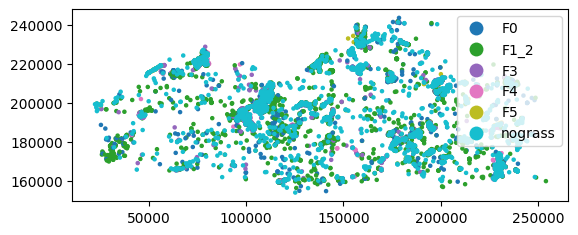

In [172]:
datagrassbwk2020.plot(column="Level4", legend=True, markersize=5)


# Creat full dataset

In [173]:
points_ee = datagrassbwk2020.to_crs("EPSG:4326")
points_ee


,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (2.68385 50.88116),NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (2.68494 50.87955),NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (2.68243 50.88074),NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (2.68271 50.88057),NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (2.68281 50.88057),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10765,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (4.86518 50.91372),kw + kh(qa),204,gh
644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (4.60237 51.42798),ur + kb,a,gh
14830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (3.76393 51.11287),spoor,204,gh
13905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (3.80133 51.15604),n + gml,203,gh


In [174]:
import ee
try:
    ee.Initialize(project="ee-sebastiaanverbesselt")
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

print('Earth Engine version:', ee.__version__)
print('geemap version:', geemap.__version__)



Earth Engine version: 1.7.30
geemap version: 0.38.0


In [175]:
def gdf_to_ee(gdf):
    features = []
    for _, row in gdf.iterrows():
        geom = ee.Geometry.Point([row.geometry.x, row.geometry.y])
        features.append(
            ee.Feature(geom, {
                "id": row.name,
                "class": str(row["Level4"]) # Fixed: extracts the actual row value (e.g., 'F0', 'nograss')
            })
        )
    return ee.FeatureCollection(features)

fc = gdf_to_ee(points_ee)


In [176]:
collection_id = "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"

In [177]:
# Filter the collection for your year

image_coll = (
    ee.ImageCollection(collection_id)
    .filterDate("2020-01-01", "2021-01-01")
)

# Mosaic the overlapping UTM tiles into a single coherent image
image = image_coll.mosaic()

samples_fc = image.sampleRegions(
    collection=fc,
    scale = 10,
    geometries=True
)

samples_fc

/usr/local/lib/python3.12/dist-packages/IPython/core/formatters.py:345: UserWarning: Getting info failed with: 'Collection query aborted after accumulating over 5000 elements.'. Falling back to string repr.
  return method()


In [178]:
# Use Earth Engine's computeFeatures API to stream pages of vector data
# directly into a native GeoPandas GeoDataFrame
embeddings_gdf = ee.data.computeFeatures({
    'expression': samples_fc,
    'fileFormat': 'GEOPANDAS_GEODATAFRAME'
})

# Explicitly re-assign the WGS 84 Coordinate Reference System
embeddings_gdf.crs = 'EPSG:4326'

In [179]:
embeddings_gdf

,geometry,A00,A01,A02,A03,A04,A05,A06,A07,A08,...,A56,A57,A58,A59,A60,A61,A62,A63,class,id
0,POINT (2.68385 50.88116),-0.206936,-0.228897,-0.135886,0.055363,0.079723,-0.079723,0.124567,-0.035433,0.119093,...,-0.108512,-0.022207,0.000984,-0.059116,0.141730,-0.119093,-0.048228,-0.141730,F1_2,0
1,POINT (2.68493 50.87954),-0.199862,-0.192910,-0.221453,0.098424,0.041584,-0.071111,0.130165,0.041584,0.124567,...,-0.119093,-0.048228,-0.008858,-0.015748,0.062991,-0.098424,-0.017778,-0.032541,F1_2,1
2,POINT (2.68241 50.88071),-0.214133,-0.236463,-0.166336,0.015748,0.055363,-0.038447,0.124567,-0.119093,0.093564,...,-0.088827,-0.071111,0.071111,-0.141730,0.108512,-0.130165,0.032541,-0.093564,F1_2,2
3,POINT (2.68268 50.88053),-0.214133,-0.244152,-0.192910,-0.008858,0.066990,-0.029773,0.119093,-0.153787,0.075356,...,-0.088827,-0.079723,0.084214,-0.186082,0.108512,-0.098424,-0.044844,-0.084214,F1_2,3
4,POINT (2.68277 50.88053),-0.214133,-0.221453,-0.172795,-0.010396,0.071111,-0.022207,0.135886,-0.147697,0.075356,...,-0.084214,-0.075356,0.093564,-0.186082,0.103406,-0.108512,-0.048228,-0.098424,F1_2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,POINT (4.86514 50.91368),-0.228897,-0.166336,-0.172795,0.071111,0.006151,-0.214133,0.066990,0.022207,0.135886,...,-0.022207,-0.000984,-0.071111,-0.108512,0.059116,-0.179377,-0.079723,-0.141730,nograss,10765
9547,POINT (4.60238 51.42797),-0.206936,-0.284444,-0.214133,0.088827,0.022207,-0.214133,0.113741,0.071111,0.055363,...,0.022207,-0.022207,-0.027128,-0.012057,0.071111,-0.108512,-0.029773,-0.108512,nograss,644
9548,POINT (3.7639 51.11284),-0.214133,-0.310096,-0.206936,-0.029773,0.088827,-0.113741,0.012057,-0.055363,0.098424,...,0.027128,-0.027128,-0.015748,-0.084214,0.098424,-0.035433,-0.062991,-0.141730,nograss,14830
9549,POINT (3.80136 51.15605),-0.166336,-0.244152,-0.141730,-0.041584,0.024606,-0.206936,-0.004983,-0.103406,0.041584,...,0.055363,-0.048228,-0.010396,-0.088827,0.027128,-0.062991,-0.022207,-0.055363,nograss,13905


In [180]:
embeddings_gdf.to_csv("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputAlphaEarthEmbeddings/AlphaEarth2020.csv") # Now saved in WGS 84